In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.ops import unary_union, linemerge

In [2]:
gdf = gpd.read_file("C:/Users/isabe/Downloads/testingg.json")
gdf.to_file("ligeia_west_coastline_short.geojson", driver="GeoJSON")

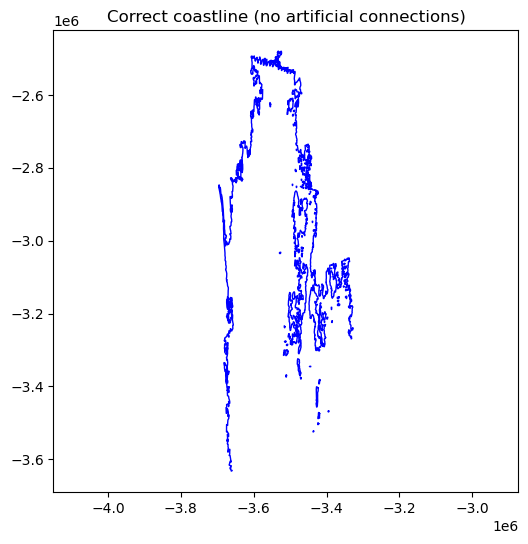

In [3]:
plt.figure(figsize=(6,6))

for geom in gdf.geometry:
    coords = list(geom.coords)
    x = [c[0] for c in coords]
    y = [-c[1] for c in coords]
    plt.plot(y, x, color="blue", linewidth=1)

plt.axis("equal")
plt.title("Correct coastline (no artificial connections)")
plt.show()

9


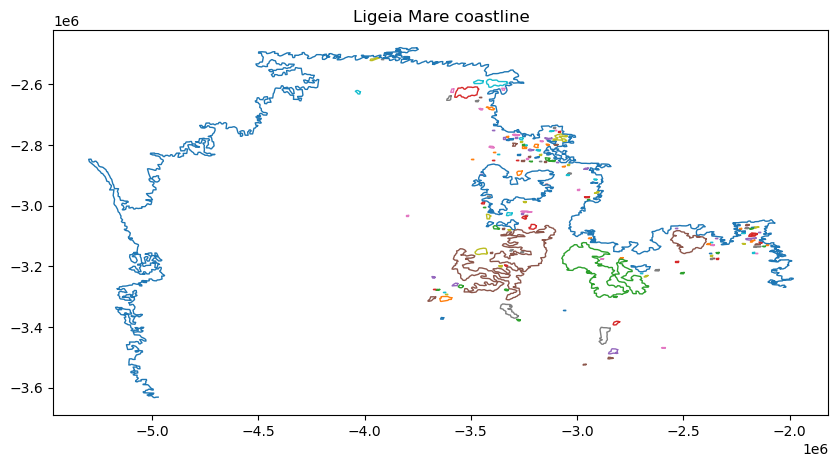

In [4]:
# collect all coords first
all_x = []
all_y = []

for geom in gdf.geometry:
    coords = np.array(geom.coords)
    all_x.extend(coords[:, 0])
    all_y.extend(coords[:, 1])

all_x = np.array(all_x)
all_y = np.array(all_y)

# calculate stretch factor to match ArcGIS-looking proportions
x_range = all_x.max() - all_x.min()
y_range = all_y.max() - all_y.min()

stretch = 9
print(stretch)
plt.figure(figsize=(10, 5))

for geom in gdf.geometry:
    coords = np.array(geom.coords)
    x = coords[:, 0]
    y = coords[:, 1]

    # center and stretch vertically
    x_plot = x
    y_plot = (y - all_y.mean()) * stretch + all_y.mean()

    plt.plot(-y_plot, x_plot, linewidth=1)


plt.title("Ligeia Mare coastline")
plt.show()

In [ ]:
print(gdf)
print(gdf.geom_type)